## E-Commerce Sales & Profit Analysis

## 1.0 BACKGROUND OF STUDY

The data is about e-commerce which consist of 3500 e-commerce order in 7 key feature which is order date,product name,category,region,quantity,sales and profit. The data capture multiple market segments across different regions in the north,east,west and south and distict product spaces including office supply,electronics and accessories.

## 2.0 OBJECTIVE OF THE STUDY

The objective of this study is to :
- Identify top performing products and categories
- Analyze regional sales performance and demand
- Analyze discount and pricing efficiency 

## 3.0 RAW DATASET

To start, we import the data and clean it to prepare for next step which is preparing the dashboard.

In [23]:
import pandas as pd

data=pd.read_csv("ecommerce_sales_data (2).csv")
print(data)


      Order Date Product Name     Category Region  Quantity  Sales   Profit
0     2024-12-31      Printer       Office  North         4   3640   348.93
1     2022-11-27        Mouse  Accessories   East         7   1197   106.53
2     2022-05-11       Tablet  Electronics  South         5   5865   502.73
3     2024-03-16        Mouse  Accessories  South         2    786   202.87
4     2022-09-10        Mouse  Accessories   West         1    509   103.28
...          ...          ...          ...    ...       ...    ...      ...
3495  2023-02-15      Monitor  Accessories  North         4   4064   771.16
3496  2022-09-18      Monitor  Accessories   East         1   1117   119.89
3497  2022-04-12       Laptop  Electronics  South         4    260    66.02
3498  2022-01-18      Printer       Office  South         3    222    50.28
3499  2024-11-01   Smartwatch  Electronics   East         9  10530  1777.32

[3500 rows x 7 columns]


In [25]:
data['Order Date'] = pd.to_datetime(data['Order Date'],errors='coerce' )
print(data)

     Order Date Product Name     Category Region  Quantity  Sales   Profit
0    2024-12-31      Printer       Office  North         4   3640   348.93
1    2022-11-27        Mouse  Accessories   East         7   1197   106.53
2    2022-05-11       Tablet  Electronics  South         5   5865   502.73
3    2024-03-16        Mouse  Accessories  South         2    786   202.87
4    2022-09-10        Mouse  Accessories   West         1    509   103.28
...         ...          ...          ...    ...       ...    ...      ...
3495 2023-02-15      Monitor  Accessories  North         4   4064   771.16
3496 2022-09-18      Monitor  Accessories   East         1   1117   119.89
3497 2022-04-12       Laptop  Electronics  South         4    260    66.02
3498 2022-01-18      Printer       Office  South         3    222    50.28
3499 2024-11-01   Smartwatch  Electronics   East         9  10530  1777.32

[3500 rows x 7 columns]


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3500 non-null   datetime64[ns]
 1   Product Name  3500 non-null   object        
 2   Category      3500 non-null   object        
 3   Region        3500 non-null   object        
 4   Quantity      3500 non-null   int64         
 5   Sales         3500 non-null   int64         
 6   Profit        3500 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 191.5+ KB


In [27]:
data.describe()

,Order Date,Quantity,Sales,Profit
count,3500,3500.000000,3500.000000,3500.000000
mean,2023-07-13 00:53:53.828571648,4.931714,3047.966000,527.047203
min,2022-01-01 00:00:00,1.000000,51.000000,6.970000
25%,2022-10-16 18:00:00,3.000000,1049.500000,158.695000
50%,2023-07-21 12:00:00,5.000000,2350.500000,361.070000
75%,2024-04-16 06:00:00,7.000000,4537.000000,729.125000
max,2024-12-31 00:00:00,9.000000,10782.000000,2946.930000
std,NaN,2.575895,2440.213237,504.139732


In [28]:
data.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [29]:
data.duplicated().sum()

np.int64(0)

In [30]:
data=pd.read_csv("ecommerce_sales_data (2).csv",index_col="Order Date")
print(data)

           Product Name     Category Region  Quantity  Sales   Profit
Order Date                                                           
2024-12-31      Printer       Office  North         4   3640   348.93
2022-11-27        Mouse  Accessories   East         7   1197   106.53
2022-05-11       Tablet  Electronics  South         5   5865   502.73
2024-03-16        Mouse  Accessories  South         2    786   202.87
2022-09-10        Mouse  Accessories   West         1    509   103.28
...                 ...          ...    ...       ...    ...      ...
2023-02-15      Monitor  Accessories  North         4   4064   771.16
2022-09-18      Monitor  Accessories   East         1   1117   119.89
2022-04-12       Laptop  Electronics  South         4    260    66.02
2022-01-18      Printer       Office  South         3    222    50.28
2024-11-01   Smartwatch  Electronics   East         9  10530  1777.32

[3500 rows x 6 columns]


In [31]:
data = data.sort_values('Order Date')
print(data)

           Product Name     Category Region  Quantity  Sales   Profit
Order Date                                                           
2022-01-01        Mouse  Accessories   East         3   3474   565.00
2022-01-01      Monitor  Accessories  South         8   1296   273.97
2022-01-01       Tablet  Electronics  North         9   9234  2523.67
2022-01-01   Headphones  Accessories  South         7   3941   628.96
2022-01-01     Keyboard  Accessories   East         6   6372   570.75
...                 ...          ...    ...       ...    ...      ...
2024-12-30   Headphones  Accessories   West         9   8703  1562.88
2024-12-30        Mouse  Accessories  North         1    746   131.25
2024-12-30       Camera  Electronics  North         1    379    39.41
2024-12-31   Smartphone  Electronics   West         6    930   213.60
2024-12-31      Printer       Office  North         4   3640   348.93

[3500 rows x 6 columns]


In [32]:
data.to_csv('clean_data_e-commerce.csv', index=False)

After exploring the data, we discover that there is no corrupted data but we removed the index collumn and changed it into order date to make it look cleaner. After that, we saved the data.

## 4.0 DASHBOARD

### 4.1 Data aggregate

In [33]:
data.aggregate(["min"])

,Product Name,Category,Region,Quantity,Sales,Profit
min,Camera,Accessories,East,1,51,6.97


In [34]:
data.aggregate(["max"])


,Product Name,Category,Region,Quantity,Sales,Profit
max,Tablet,Office,West,9,10782,2946.93


### 4.2 Graph

In [37]:
import matplotlib.pyplot as plt

TypeError: line() got an unexpected keyword argument 'ax'. Did you mean 'x'?

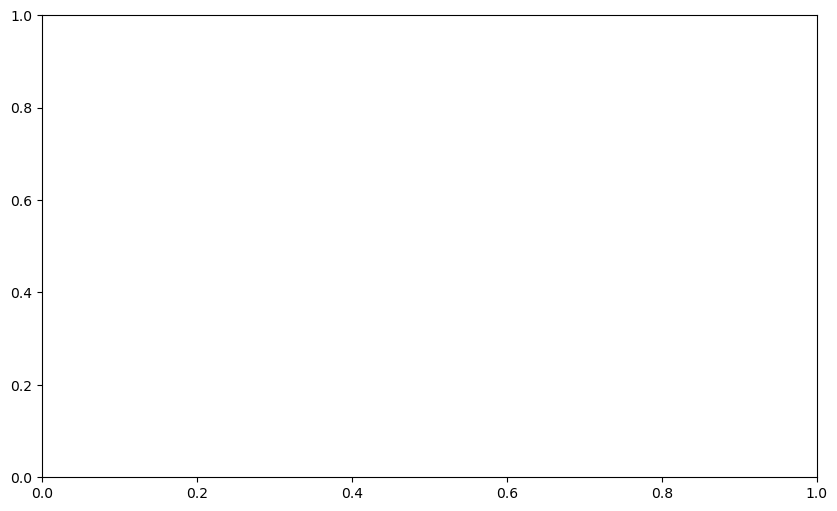

In [39]:
fig, ax = plt.subplots(figsize = (10, 6))
 

data.plot(kind = 'line',
        x = 'Order Date',
        y = 'Sales',
        ax = ax)

plt.show()